Required Battery Capacity: 39.73 Wh


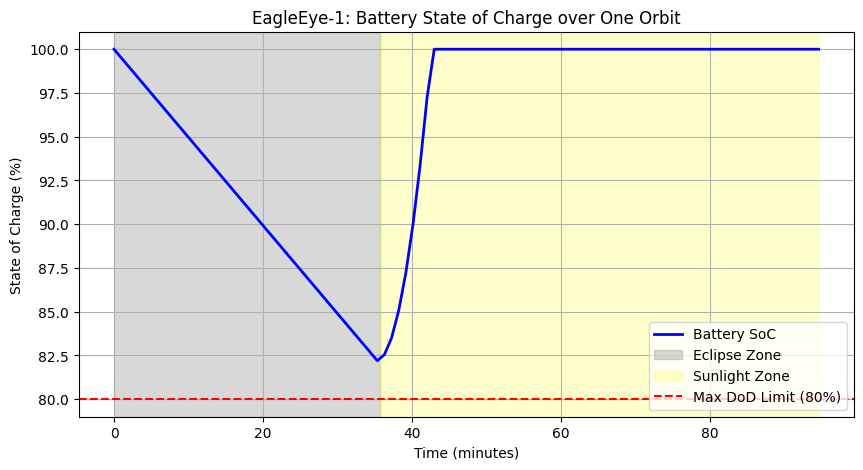

In [ ]:
# EPS Sizing and Energy Balance Analysis
# EagleEye-1 Mission

import numpy as np
import matplotlib.pyplot as plt

# 1. ORBITAL PARAMETERS (From previous physics script)
t_eclipse_min = 35.76
t_sunlight_min = 58.85
t_total_min = t_eclipse_min + t_sunlight_min

# 2. POWER BUDGET ASSUMPTIONS (Watts)
P_eclipse_W = 12.0  # Heaters, ADCS, and On-Board Computer
P_sunlight_W = 25.0 # Adds MWIR Payload [REQ-PAY-010] and Communications

# 3. BATTERY SIZING [REQ-EPS-020]
# Energy required during eclipse (Watt-hours)
E_req_Wh = P_eclipse_W * (t_eclipse_min / 60.0)

DoD_max = 0.20 # Maximum Depth of Discharge (20%)
efficiency_loss = 0.90 # 10% loss in power distribution

# Required battery capacity
C_bat_Wh = E_req_Wh / (DoD_max * efficiency_loss)

print(f"Required Battery Capacity: {C_bat_Wh:.2f} Wh")

# 4. SIMULATION: STATE OF CHARGE (SoC) OVER ONE ORBIT
time_array = np.linspace(0, t_total_min, 100)
soc_array = np.zeros_like(time_array)

# Initial state: 100% full before entering eclipse
current_energy = C_bat_Wh

for i, t in enumerate(time_array):
    if t <= t_eclipse_min:
        # Discharging during eclipse
        energy_drain = P_eclipse_W * (t / 60.0)
        soc_array[i] = ((current_energy - energy_drain) / C_bat_Wh) * 100
    else:
        # Charging during sunlight (Assuming solar panels generate 40W)
        P_solar_gen = 40.0
        net_power = P_solar_gen - P_sunlight_W
        energy_added = net_power * ((t - t_eclipse_min) / 60.0)
        soc_array[i] = min(100, soc_array[i-1] + (energy_added / C_bat_Wh * 100))

# 5. VISUALIZATION
plt.figure(figsize=(10, 5))
plt.plot(time_array, soc_array, 'b-', linewidth=2, label='Battery SoC')
plt.axvspan(0, t_eclipse_min, color='gray', alpha=0.3, label='Eclipse Zone')
plt.axvspan(t_eclipse_min, t_total_min, color='yellow', alpha=0.2, label='Sunlight Zone')
plt.axhline(y=(1.0 - DoD_max)*100, color='r', linestyle='--', label='Max DoD Limit (80%)')

plt.title('EagleEye-1: Battery State of Charge over One Orbit')
plt.xlabel('Time (minutes)')
plt.ylabel('State of Charge (%)')
plt.grid(True)
plt.legend(loc='lower right')
plt.show()